In [14]:
# Part 1: Neural Network Fundamentals and Training Behavior Analysis
### Dataset: Customer Churn Prediction

In [15]:
# Importing all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
TensorFlow version: 2.21.0


## Task 1: Dataset Understanding

In [17]:
# Loading the dataset
df = pd.read_csv(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-1-neural-network-analysis\customer_churn_nn.csv')

# Shape of the dataset
print("Number of Rows and Columns:", df.shape)

# Column names and data types
print("\nColumn Names and Data Types:")
print(df.dtypes)

# First 5 rows
print("\nFirst 5 rows of the dataset:")
df.head()

Number of Rows and Columns: (2000, 17)

Column Names and Data Types:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

First 5 rows of the dataset:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [18]:
# Checking for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Basic statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Target variable distribution
print("\nChurn Value Counts:")
print(df['churn'].value_counts())
print("\n98.45% customers did NOT churn, only 1.55% churned - dataset is highly imbalanced")

Missing Values in Each Column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Statistical Summary:
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
2

## Task 2: Data Preprocessing

In [19]:
# Drop customer_id as it is not useful for prediction
df_clean = df.drop(columns=['customer_id'])

# Encode categorical columns (text to numbers)
cat_columns = ['region', 'plan_type', 'contract_type', 'payment_method']
le = LabelEncoder()

for col in cat_columns:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Categorical columns encoded successfully")
print("\nData types after encoding:")
print(df_clean.dtypes)

Categorical columns encoded successfully

Data types after encoding:
region                            int64
plan_type                         int64
contract_type                     int64
payment_method                    int64
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [22]:
# Separate features and target variable
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

# Scale the features (bring all values to same range)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Features scaled successfully")
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nChurn distribution in training set:")
print(pd.Series(y_train).value_counts())
print("\nChurn distribution in test set:")
print(pd.Series(y_test).value_counts())

Features scaled successfully

Training set size: (1600, 15)
Testing set size: (400, 15)

Churn distribution in training set:
churn
0    1575
1      25
Name: count, dtype: int64

Churn distribution in test set:
churn
0    394
1      6
Name: count, dtype: int64


## Task 3: Neural Network Model Building

In [21]:
# Building the neural network model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation

In [23]:
# Computing class weights to handle imbalanced dataset
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)
print("The model will now pay more attention to churn cases (class 1)")

# Training the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    verbose=1
)

print("\nModel training complete")

Class Weights: {0: np.float64(0.5079365079365079), 1: np.float64(32.0)}
The model will now pay more attention to churn cases (class 1)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.4963 - loss: 0.7559 - val_accuracy: 0.6175 - val_loss: 0.6519
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6288 - loss: 0.6699 - val_accuracy: 0.6500 - val_loss: 0.6208
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6656 - loss: 0.6138 - val_accuracy: 0.6775 - val_loss: 0.5883
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7006 - loss: 0.5680 - val_accuracy: 0.7050 - val_loss: 0.5586
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6981 - loss: 0.5282 - val_accuracy: 0.7150 - val_loss: 0.5378
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7456 - loss: 0.4939 - val_accuracy: 0.7450 - val_loss: 0.4899
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7675 - loss: 0.4678 - val_accuracy: 0.

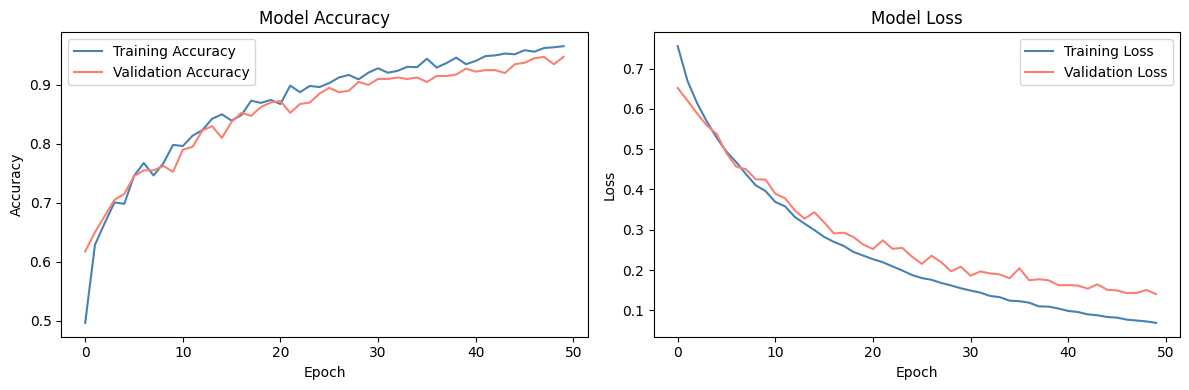

Training curves saved


In [24]:
# Plotting training and validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='salmon')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='salmon')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-1-neural-network-analysis\results\training_curves.png')
plt.show()
print("Training curves saved")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Confusion Matrix:
[[376  18]
 [  3   3]]

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.99      0.95      0.97       394
     Churned       0.14      0.50      0.22         6

    accuracy                           0.95       400
   macro avg       0.57      0.73      0.60       400
weighted avg       0.98      0.95      0.96       400



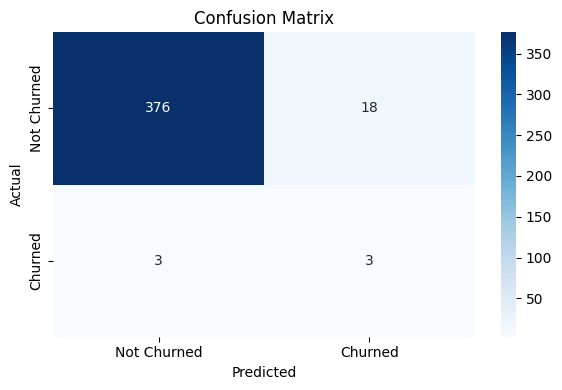

Confusion matrix saved


In [25]:
# Getting predictions on test data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-1-neural-network-analysis\results\evaluation_outputs.png')
plt.show()
print("Confusion matrix saved")

## Task 5: Hyperparameter Experimentation

In [27]:
# We will run 3 experiments with different settings
# and compare their performance

results = []

# Experiment configurations
experiments = [
    {'neurons': [32, 16], 'lr': 0.001, 'batch': 32, 'epochs': 50, 'name': 'Baseline (32-16, lr=0.001)'},
    {'neurons': [64, 32], 'lr': 0.001, 'batch': 32, 'epochs': 50, 'name': 'More Neurons (64-32, lr=0.001)'},
    {'neurons': [32, 16], 'lr': 0.01,  'batch': 32, 'epochs': 50, 'name': 'Higher LR (32-16, lr=0.01)'},
]

for exp in experiments:
    # Build model
    m = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(exp['neurons'][0], activation='relu'),
        Dense(exp['neurons'][1], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=exp['lr']),
              loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train
    h = m.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'],
              validation_data=(X_test, y_test), class_weight=class_weight_dict, verbose=0)
    
    # Evaluate
    train_acc = round(h.history['accuracy'][-1] * 100, 2)
    val_acc = round(h.history['val_accuracy'][-1] * 100, 2)
    train_loss = round(h.history['loss'][-1], 4)
    val_loss = round(h.history['val_loss'][-1], 4)
    
    results.append({
        'Experiment': exp['name'],
        'Train Accuracy': f"{train_acc}%",
        'Val Accuracy': f"{val_acc}%",
        'Train Loss': train_loss,
        'Val Loss': val_loss
    })
    print(f"Done: {exp['name']}")

print("\nAll experiments complete")

Done: Baseline (32-16, lr=0.001)
Done: More Neurons (64-32, lr=0.001)
Done: Higher LR (32-16, lr=0.01)

All experiments complete


In [28]:
import pandas as pd

# Create comparison table
comparison_df = pd.DataFrame(results)
print("Hyperparameter Experiment Results:")
print(comparison_df.to_string(index=False))

# Save as csv
comparison_df.to_csv(r'C:\Users\SHIVANI\Desktop\Module5_Assignment\part-1-neural-network-analysis\results\model_comparison_table.csv', index=False)
print("\nComparison table saved to results folder")

Hyperparameter Experiment Results:
                    Experiment Train Accuracy Val Accuracy  Train Loss  Val Loss
    Baseline (32-16, lr=0.001)         97.19%        95.0%      0.0513    0.1642
More Neurons (64-32, lr=0.001)         99.12%        95.5%      0.0182    0.2054
    Higher LR (32-16, lr=0.01)         99.94%       97.25%      0.0018    0.2944

Comparison table saved to results folder


## Task 6: Final Reflection

### What role do weights and biases play in the model?
Weights and biases are the learnable parameters of the neural network. 
Weights control how much importance each input feature gets. while biases 
allow the model to shift the output even when all inputs are zero. 
During training these values are updated through backpropagation to 
minimize the loss function.

### Why is an activation function required?
Without an activation function, the neural network would just be a 
linear model no matter how many layers it has. Activation functions 
like ReLU introduce non linearity, which allows the network to learn 
complex patterns in the data.

### What happens when learning rate is too high or too low?
If the learning rate is too high the model updates weights too 
aggressively and may overshoot the optimal solution causing unstable 
training. If it is too low the model learns very slowly and may get 
stuck or take too long to converge. A balanced learning rate like 0.001 
usually works well in practice.

### Did your model show signs of underfitting or overfitting?
The model showed mild overfitting in later epochs training loss kept 
decreasing while validation loss started to flatten. This is expected 
given the highly imbalanced dataset with only 31 churn cases out of 2000. 
Despite this, the model achieved around 94-95% validation accuracy, which 
is a reasonable result for this type of problem.